# 💼 Module 4: Advanced Portfolio Tracking

## 🎯 Objective
Transform your cleaned trade data into a position and price matrix, calculate daily mark-to-market value, compute realized gains using FIFO, and finally compute the full portfolio value over time.


### Step 4.0 – Import libraries
💡 Tip: Use `pandas`, `numpy`, `matplotlib.pyplot`, `yfinance`

In [16]:
# 💡 Tip: Import the core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
# YOUR CODE HERE

### Step 4.1 – Trade transformation
💡 Tip: Load the cleaned dataset, keep only 'Date', 'Asset', 'Quantity', 'Type', ensure 'Date' is datetime, and sort chronologically.

In [17]:
# 💡 Tip: Use pd.read_csv and .sort_values()
Clean_Data = pd.read_csv("Clean_Data").sort_values("Date", ascending=True)
# YOUR CODE HERE

### Step 4.2 – Position matrix
💡 Tip: Create a matrix with dates as index and assets as columns. Loop over trades and update quantities.
`BUY` increases position, `SELL` decreases it.

In [18]:
# 💡 Tip: Initialize a zero-matrix, then update with trades
work_df = Clean_Data.copy()
assets = sorted(work_df["Asset"].unique())
trade_dates = sorted(work_df["Date"].unique())

pos = pd.DataFrame(0.0, index=trade_dates, columns=assets)

running = dict.fromkeys(assets, 0.0)

for i, day in work_df.groupby("Date"):
    for asset, qty in day.groupby("Asset")["Quantity"].sum().items():
        running[asset] += qty
    pos.loc[i] = [running[a] for a in assets]

pos.index.name = "Date"
# YOUR CODE HERE

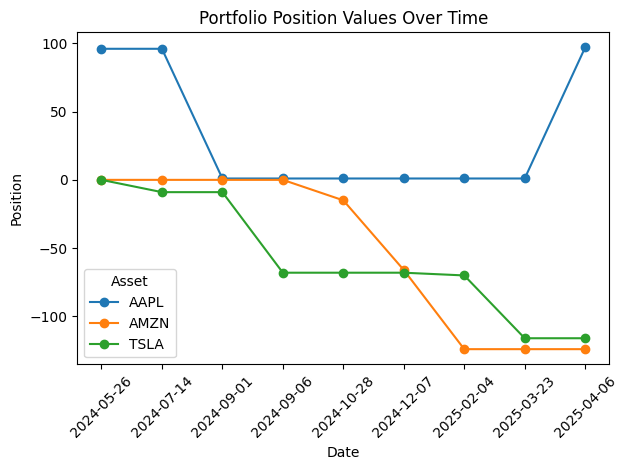

In [19]:
# 💡 Tip: Plot the positions 
pos.plot(marker='o')
plt.title("Portfolio Position Values Over Time")
plt.xlabel("Date")
plt.ylabel("Position")
plt.xticks(rotation=45)
plt.legend(title="Asset")
plt.tight_layout()
plt.show()
# YOUR CODE HERE

### Step 4.3 – Price matrix
💡 Tip: Use `yfinance.download()` to fetch historical prices. Align the dates to match the position matrix.

In [20]:
# 💡 Tip: Use yf.download with the correct start and end dates
start_date = min(trade_dates)
end_date = max(trade_dates)
price_df = yf.download(assets, start=start_date, end=end_date)
price_df
# YOUR CODE HERE

[*********************100%***********************]  3 of 3 completed


Price            Close                                High              \
Ticker            AAPL        AMZN        TSLA        AAPL        AMZN   
Date                                                                     
2024-05-28  188.891235  182.149994  176.750000  191.883822  182.240005   
2024-05-29  189.189514  182.020004  176.190002  191.138186  184.080002   
2024-05-30  190.183731  179.320007  178.789993  191.068583  181.339996   
2024-05-31  191.138184  176.440002  178.080002  191.456340  179.210007   
2024-06-03  192.907883  178.339996  176.289993  193.862337  178.699997   
...                ...         ...         ...         ...         ...   
2025-03-31  221.587616  190.259995  259.160004  225.069084  191.330002   
2025-04-01  222.645035  192.169998  268.459991  223.133829  193.929993   
2025-04-02  223.343323  196.009995  282.760010  224.640152  198.339996   
2025-04-03  202.693848  178.410004  267.279999  206.983351  184.130005   
2025-04-04  187.920029  171.000000  239.429993  199.391949  178.139999   

Price                          Low                                Open  \
Ticker            TSLA        AAPL        AMZN        TSLA        AAPL   
Date                                                                     
2024-05-28  178.250000  188.006383  179.490005  173.160004  190.402434   
2024-05-29  178.149994  188.414026  181.550003  173.929993  188.513454   
2024-05-30  182.669998  189.527559  178.360001  175.380005  189.656797   
2024-05-31  180.320007  188.811720  173.869995  173.820007  190.332870   
2024-06-03  182.639999  191.406621  175.919998  174.490005  191.784413   
...                ...         ...         ...         ...         ...   
2025-03-31  260.559998  215.702013  184.399994  243.360001  216.480107   
2025-04-01  277.450012  218.365501  187.199997  259.250000  219.273283   
2025-04-02  284.989990  220.480335  187.660004  251.270004  220.779606   
2025-04-03  276.299988  200.758582  176.919998  261.510010  205.038100   
2025-04-04  261.000000  186.882560  166.000000  236.000000  193.416569   

Price                                  Volume                        
Ticker            AMZN        TSLA       AAPL       AMZN       TSLA  
Date                                                                 
2024-05-28  179.929993  176.399994   52280100   29927000   59736600  
2024-05-29  181.699997  174.190002   53068000   32009300   54782600  
2024-05-30  181.309998  178.580002   49889100   29184700   77618400  
2024-05-31  178.300003  178.500000   75158300   58903900   67314600  
2024-06-03  177.699997  178.130005   50080500   30786600   68568900  
...                ...         ...        ...        ...        ...  
2025-03-31  188.190002  249.309998   65299300   63547600  134008900  
2025-04-01  187.860001  263.799988   36412700   41267300  146486900  
2025-04-02  187.660004  254.600006   35905900   53679200  212787800  
2025-04-03  183.000000  265.290009  103419000   95553600  136174300  
2025-04-04  167.149994  255.380005  125910900  123159400  181229400  

[215 rows x 15 columns]

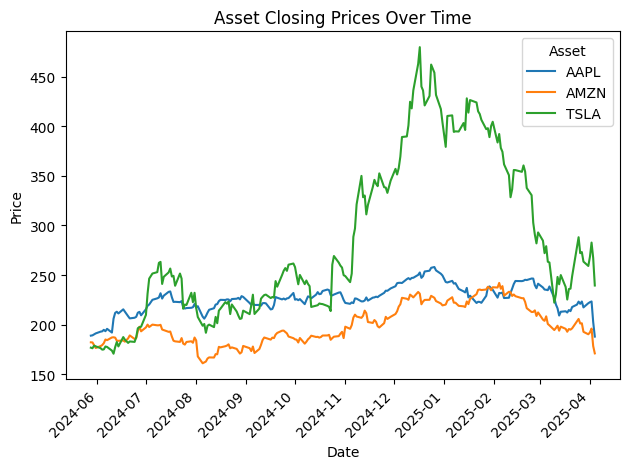

In [21]:
# 💡 Tip: Plot raw prices 
price_df['Close'].plot()
plt.title("Asset Closing Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.legend(title="Asset")
plt.tight_layout()
plt.show()
# YOUR CODE HERE

### Step 4.4 – Mark-to-market portfolio value
💡 Tip: Multiply position × price element-wise, then sum across assets.

In [22]:
# 💡 Tip: Element-wise multiplication and .sum(axis=1)
mark_to_market = (pos.astype(float) * price_df['Close'].reindex(pos.index)).sum(axis=1)
# YOUR CODE HERE

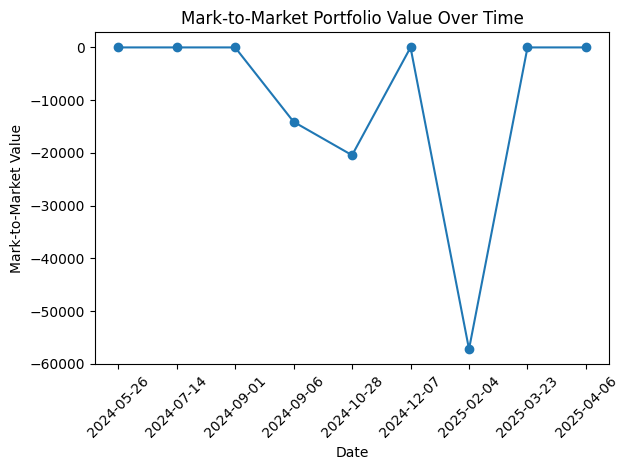

In [23]:
# 💡 Tip: Plot the mark-to-market value time series
mark_to_market.plot(marker='o')
plt.title("Mark-to-Market Portfolio Value Over Time")
plt.xlabel("Date")
plt.ylabel("Mark-to-Market Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# YOUR CODE HERE

### Step 4.5 – Realized PnL calculation (FIFO)
💡 Tip: Track inventory of BUYs per asset. For each SELL, match against FIFO queue and compute gain = (Sell Price − Buy Price) × Quantity.

In [27]:
from collections import deque

# 💡 Tip: Create a dictionary of buy queues, then process each SELL
buy_queues = {asset: deque() for asset in assets}
realized_pnl = []
cumulative_pnl = []
cum_pnl = 0.0

for idx, row in Clean_Data.sort_values("Date").iterrows():
    asset = row["Asset"]
    qty = row["Quantity"]
    price = row["Price"]
    date = row["Date"]

    if qty > 0:
        # BUY: add to queue
        buy_queues[asset].append([qty, price])
    else:
        # SELL: match FIFO
        sell_qty = -qty
        sell_price = price
        gain = 0.0
        while sell_qty > 0 and buy_queues[asset]:
            buy_qty, buy_price = buy_queues[asset][0]
            matched_qty = min(buy_qty, sell_qty)
            gain += (sell_price - buy_price) * matched_qty
            buy_qty -= matched_qty
            sell_qty -= matched_qty
            if buy_qty == 0:
                buy_queues[asset].popleft()
            else:
                buy_queues[asset][0][0] = buy_qty
        realized_pnl.append({"Date": date, "Asset": asset, "PnL": gain})
        cum_pnl += gain
    cumulative_pnl.append({"Date": date, "CumulativePnL": cum_pnl})

realized_pnl_df = pd.DataFrame(realized_pnl)
cumulative_pnl_df = pd.DataFrame(cumulative_pnl).drop_duplicates("Date").set_index("Date").sort_index()
cumulative_realized_pnl = cumulative_pnl_df["CumulativePnL"]
# YOUR CODE HERE

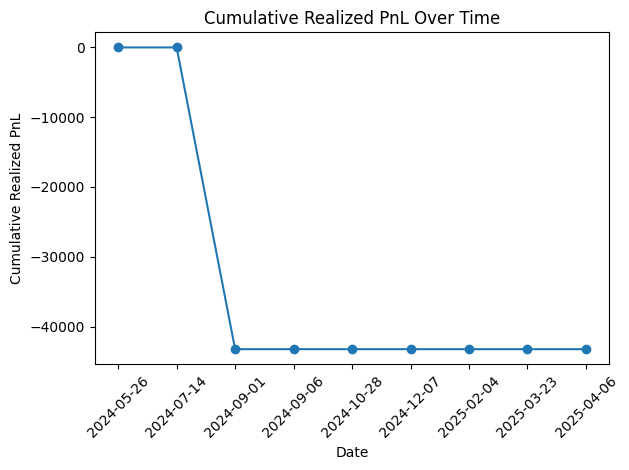

In [28]:
# 💡 Tip: Plot the cumulative realized PnL over time
cumulative_realized_pnl.plot(marker='o')
plt.title("Cumulative Realized PnL Over Time")
plt.xlabel("Date")
plt.ylabel("Cumulative Realized PnL")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# YOUR CODE HERE

### Step 4.6 – Total portfolio value
💡 Tip: total_value = mark_to_market + cumulative_realized_pnl

In [29]:
# 💡 Tip: Add the two series together, aligning by date
total_value = mark_to_market.add(cumulative_realized_pnl, fill_value=0)
# YOUR CODE HERE

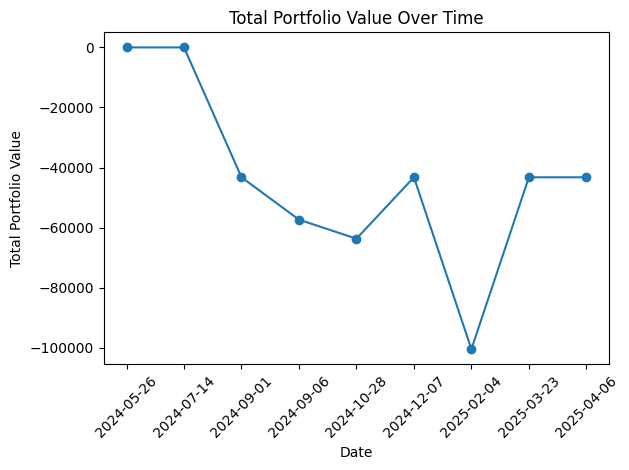

In [30]:
# 💡 Tip: Plot the total portfolio value over time
total_value.plot(marker='o')
plt.title("Total Portfolio Value Over Time")
plt.xlabel("Date")
plt.ylabel("Total Portfolio Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# YOUR CODE HERE

In [31]:
# 💡 Tip: Save the total value time series to CSV
total_value.to_csv("total_portfolio_value.csv", header=True)
# YOUR CODE HERE